In [ ]:
# Cell 1 - Mount Drive and set paths

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/Fault Localization'
TRAIN_DIR = f'{BASE_DIR}/Dataset/train'
VALID_DIR = f'{BASE_DIR}/Dataset/valid'
TEST_DIR  = f'{BASE_DIR}/Dataset/test'
SAVE_DIR  = f'{BASE_DIR}/Models'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print("Paths set.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths set.


In [ ]:
# Cell 2 - Imports

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU available: False


In [ ]:
# Cell 3 - Configuration

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-4

# Folders are: clean (index 0) and single_hotspot (index 1)
# flow_from_directory assigns alphabetically so clean=0, single_hotspot=1
# single_hotspot is our positive class (hotspot present)
CLEAN_LABEL   = 0
HOTSPOT_LABEL = 1

print("Config set.")

Config set.


In [ ]:
# Cell 4 - Preprocessing function
# Kept exactly as your original code since it was correct
# Grayscale -> Gaussian blur -> normalize -> stack to 3 channels for DenseNet

def preprocess(img):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img
    img_blurred    = cv2.GaussianBlur(img_gray, ksize=(3, 3), sigmaX=0)
    img_normalized = img_blurred / 255.0
    if img_normalized.ndim == 2:
        img_normalized = np.stack([img_normalized] * 3, axis=-1)
    return img_normalized

In [ ]:
# Cell 5 - Data generators
#
# Why augmentation on train only:
#   Train gen gets augmentation to prevent overfitting on small datasets.
#   Val and test get only preprocessing so evaluation reflects real performance.
#   Augmentation settings match your original code.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=10,
    shear_range=0.01,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("  clean = 0, single_hotspot = 1")
print("Train samples:", train_gen.samples)
print("Val samples:  ", val_gen.samples)
print("Test samples: ", test_gen.samples)

Found 2814 images belonging to 2 classes.
Found 696 images belonging to 2 classes.
Found 697 images belonging to 2 classes.
Class indices: {'clean': 0, 'single_hotspot': 1}
  clean = 0, single_hotspot = 1
Train samples: 2814
Val samples:   696
Test samples:  697


In [10]:
# Cell 6 - Build DenseNet121 binary classifier
#
# Why DenseNet over a simple CNN:
#   Your original 3-layer CNN works but DenseNet121 is pretrained on ImageNet
#   so it already understands edges, textures, and shapes before seeing any
#   solar panel image. We just retrain the top layers to recognize hotspot patterns.
#
# Why GlobalAveragePooling instead of Flatten:
#   Flatten loses spatial structure. GlobalAveragePooling keeps spatial info
#   which is essential for Grad-CAM to correctly locate the hotspot region.
#
# Single sigmoid output: P(single_hotspot) since this is binary

def build_model(learning_rate=1e-4):

    base = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base.trainable = False   # frozen in phase 1, partially unfrozen in phase 2

    inputs = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='hotspot_output')(x)

    model = Model(inputs, outputs, name='DenseNet121_HotspotDetector')
    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_model(LR)
model.summary()


# Cell 7 - Phase 1: train only the top classifier head
# DenseNet weights are frozen here to protect pretrained features
# We only train the Dense + Dropout layers we added on top

print("Phase 1: Training classifier head with frozen DenseNet base...")

cb_phase1 = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True,
                  mode='max', verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/phase1_best.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4,
                      min_lr=1e-7, mode='max', verbose=1)
]

history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=cb_phase1,
    verbose=1
)

print(f"Phase 1 done. Best val AUC: {max(history1.history['val_auc']):.4f}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_HotspotDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hotspot_output (Dense)          │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

Phase 1: Training classifier head with frozen DenseNet base...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7131 - auc: 0.7467 - loss: 0.5522 - precision: 0.7646 - recall: 0.7818 
Epoch 1: val_auc improved from None to 0.99619, saving model to /content/drive/MyDrive/Fault Localization/Models/phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fault Localization/Models/phase1_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 795s 18s/step - accuracy: 0.8333 - auc: 0.9041 - loss: 0.3882 - precision: 0.8629 - recall: 0.8703 - val_accuracy: 0.9540 - val_auc: 0.9962 - val_loss: 0.2853 - val_precision: 0.9868 - val_recall: 0.9325 - learning_rate: 1.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9716 - auc: 0.9920 - loss: 0.1487 - precision: 0.9770 - recall: 0.9776 
Epoch 2: val_auc improved from 0.99619 to 0.99890, saving model to /content/drive/MyDrive/Fault Localization/Models/phase1_best.keras

Epoch 2: finished saving model to /con

In [11]:
# Cell 8 - Phase 2: fine-tune the last dense block of DenseNet
# Unfreeze from denseblock4 onwards and retrain with a much lower learning rate
# This adapts high-level DenseNet features to thermal solar panel images

print("Phase 2: Fine-tuning last dense block of DenseNet...")

base_model = model.get_layer('densenet121')

unfreeze_from = 'conv5_block1_0_bn'
found = False
for layer in base_model.layers:
    if layer.name == unfreeze_from:
        found = True
    layer.trainable = found

print(f"Trainable base layers: {sum(1 for l in base_model.layers if l.trainable)} "
      f"/ {len(base_model.layers)}")

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

cb_phase2 = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True,
                  mode='max', verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/final_model.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5,
                      min_lr=1e-8, mode='max', verbose=1)
]

history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=cb_phase2,
    verbose=1
)

model.save(f'{SAVE_DIR}/final_model.keras')
print("Model saved to Drive.")

Phase 2: Fine-tuning last dense block of DenseNet...
Trainable base layers: 114 / 427
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9891 - auc: 0.9996 - loss: 0.0309 - precision: 0.9875 - recall: 0.9952 
Epoch 1: val_auc improved from None to 0.99978, saving model to /content/drive/MyDrive/Fault Localization/Models/final_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fault Localization/Models/final_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 785s 17s/step - accuracy: 0.9900 - auc: 0.9995 - loss: 0.0287 - precision: 0.9881 - recall: 0.9960 - val_accuracy: 0.9957 - val_auc: 0.9998 - val_loss: 0.0157 - val_precision: 0.9950 - val_recall: 0.9975 - learning_rate: 1.0000e-05
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9914 - auc: 0.9998 - loss: 0.0234 - precision: 0.9924 - recall: 0.9942 
Epoch 2: val_auc did not improve from 0.99978
44/44 ━━━━━━━━━━━━━━━━━━━━ 710s 16s/step - accuracy: 0.9943 - auc: 0.9998 - loss: 0.0220 - precision: 0.

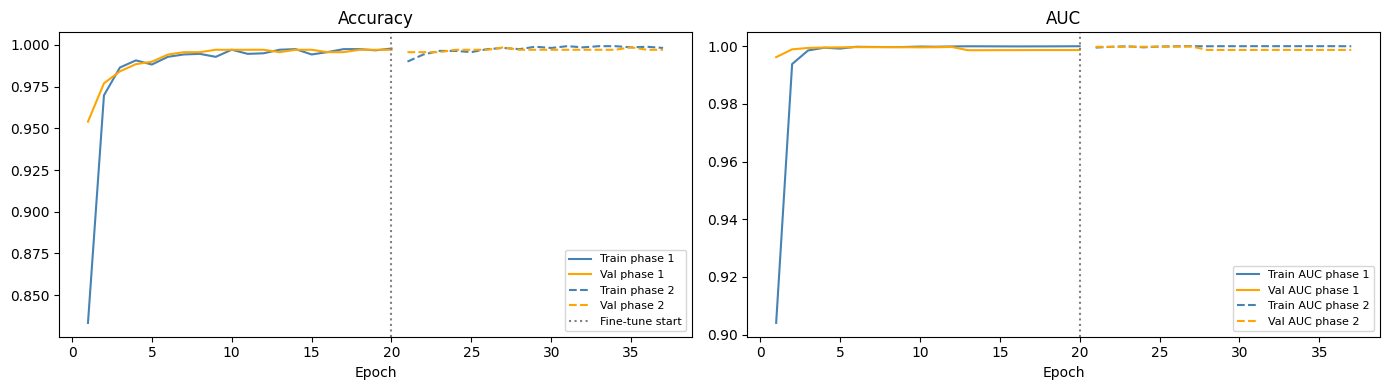

In [12]:
# Cell 9 - Plot training history across both phases

p1 = len(history1.history['accuracy'])
p2 = len(history2.history['accuracy'])
e1 = range(1, p1 + 1)
e2 = range(p1 + 1, p1 + p2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(e1, history1.history['accuracy'],     color='steelblue', label='Train phase 1')
axes[0].plot(e1, history1.history['val_accuracy'], color='orange',    label='Val phase 1')
axes[0].plot(e2, history2.history['accuracy'],     color='steelblue', linestyle='--', label='Train phase 2')
axes[0].plot(e2, history2.history['val_accuracy'], color='orange',    linestyle='--', label='Val phase 2')
axes[0].axvline(p1, color='gray', linestyle=':', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)

axes[1].plot(e1, history1.history['auc'],     color='steelblue', label='Train AUC phase 1')
axes[1].plot(e1, history1.history['val_auc'], color='orange',    label='Val AUC phase 1')
axes[1].plot(e2, history2.history['auc'],     color='steelblue', linestyle='--', label='Train AUC phase 2')
axes[1].plot(e2, history2.history['val_auc'], color='orange',    linestyle='--', label='Val AUC phase 2')
axes[1].axvline(p1, color='gray', linestyle=':')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 206s 18s/step
Test Classification Report:
                precision    recall  f1-score   support

         clean       1.00      1.00      1.00       297
single_hotspot       1.00      1.00      1.00       400

      accuracy                           1.00       697
     macro avg       1.00      1.00      1.00       697
  weighted avg       1.00      1.00      1.00       697



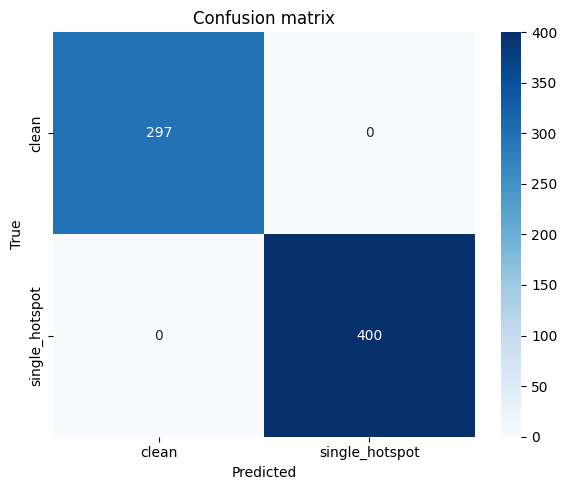

In [13]:
# Cell 10 - Evaluate on test set

y_pred_probs = model.predict(test_gen, verbose=1).flatten()
y_pred       = (y_pred_probs >= 0.5).astype(int)
y_true       = test_gen.classes

print("Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=['clean', 'single_hotspot']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'single_hotspot'],
            yticklabels=['clean', 'single_hotspot'])
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()

In [14]:
# Cell 11 - Build Grad-CAM model
#
# How Grad-CAM works here:
#   DenseNet's last conv layer produces a 7x7 spatial feature map (1024 channels).
#   We compute how much each spatial location in that map contributed to the
#   hotspot prediction. High-contribution locations get highlighted.
#   We upsample the 7x7 map back to 224x224 and draw a bounding box around
#   the brightest region — that is where the hotspot is in the image.

BASE_LAST_CONV = 'conv5_block16_2_conv'

base_model_ref = model.get_layer('densenet121')
print("Last conv layer output shape:",
      base_model_ref.get_layer(BASE_LAST_CONV).output.shape)

gradcam_model = Model(
    inputs=model.input,
    outputs=[
        base_model_ref.get_layer(BASE_LAST_CONV).output,
        model.output
    ]
)
print("Grad-CAM model ready.")

Last conv layer output shape: (None, 7, 7, 32)
Grad-CAM model ready.


In [15]:
# Cell 12 - Grad-CAM helper functions

def get_gradcam_heatmap(gradcam_model, img_array):
    """
    Computes Grad-CAM heatmap focused on the hotspot class score.
    Always targets P(hotspot) so the map shows hotspot-relevant regions
    regardless of final prediction, useful for borderline cases too.
    """
    with tf.GradientTape() as tape:
        conv_out, pred = gradcam_model(img_array, training=False)
        hotspot_score  = pred[:, 0]   # single sigmoid output = P(hotspot)

    grads        = tape.gradient(hotspot_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    feature_map  = conv_out[0]

    heatmap = (feature_map @ pooled_grads[..., tf.newaxis]).numpy().squeeze()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap


def heatmap_to_bbox(heatmap, img_size=(224, 224), threshold=0.4):
    """
    Upsamples heatmap to image size, thresholds it, and returns
    a bounding box (x, y, w, h) around the largest activated region.
    Returns (None, heatmap_resized) if nothing found above threshold.
    """
    heatmap_resized = cv2.resize(heatmap, img_size)
    binary = (heatmap_resized >= threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, heatmap_resized
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return (x, y, w, h), heatmap_resized


def blend_heatmap(original_img, heatmap_resized, alpha=0.4):
    """
    Overlays the colored Grad-CAM heatmap on the original image.
    Returns a uint8 RGB blended image.
    """
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    base = np.uint8(255 * original_img) if original_img.max() <= 1.0 else original_img.copy()
    return cv2.addWeighted(base, 1 - alpha, heatmap_color, alpha, 0)

In [16]:
# Cell 13 - Full inference function for one image

def predict_hotspot(img_path, fault_code_from_electrical=None,
                    hotspot_threshold=0.5, heatmap_threshold=0.4):
    """
    Runs the complete pipeline on a single image:
      1. Load and preprocess image
      2. Classify: clean or single_hotspot
      3. Generate Grad-CAM heatmap
      4. Compute bounding box around hotspot region

    Parameters
    ----------
    img_path                   : full path to the image file
    fault_code_from_electrical : int 0-3 from your colleague's electrical model, or None
    hotspot_threshold          : probability above which we call it a hotspot (default 0.5)
    heatmap_threshold          : Grad-CAM activation threshold for bounding box (default 0.4)

    Returns dict with all results including image arrays and bounding box coordinates.
    """
    raw = cv2.imread(img_path)
    if raw is None:
        raise FileNotFoundError(f"Could not read: {img_path}")

    raw_rgb     = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    raw_resized = cv2.resize(raw_rgb, IMG_SIZE)

    preprocessed = preprocess(raw_resized)
    img_array    = np.expand_dims(preprocessed, axis=0).astype(np.float32)

    pred_score = float(model.predict(img_array, verbose=0)[0][0])
    is_hotspot = pred_score >= hotspot_threshold

    heatmap = get_gradcam_heatmap(gradcam_model, img_array)
    bbox, heatmap_full = heatmap_to_bbox(heatmap, IMG_SIZE, heatmap_threshold)
    overlay = blend_heatmap(raw_resized, heatmap_full)

    return {
        'image_original':             raw_resized,
        'image_gradcam':              overlay,
        'heatmap':                    heatmap_full,
        'is_hotspot':                 is_hotspot,
        'hotspot_probability':        round(pred_score, 4),
        'bounding_box':               bbox,
        'fault_code_from_electrical': fault_code_from_electrical,
        'img_path':                   img_path
    }

In [17]:
# Cell 14 - Visualization function
#
# Three panel display:
#   Left   : original thermal image
#   Middle : Grad-CAM heatmap overlay (bright = where model sees hotspot)
#   Right  : bounding box on original marking the detected hotspot location
#
# Title shows image model prediction and fault code from the electrical model

def visualize_result(result, save_path=None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    is_hs    = result['is_hotspot']
    prob     = result['hotspot_probability'] * 100
    elec     = result['fault_code_from_electrical']
    elec_str = f"Electrical model fault code: {elec}" \
               if elec is not None else "Electrical fault code: not provided"
    label    = 'HOTSPOT DETECTED' if is_hs else 'Clean (no hotspot)'
    color    = 'firebrick' if is_hs else 'steelblue'

    axes[0].imshow(result['image_original'])
    axes[0].set_title('Original image', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(result['image_gradcam'])
    axes[1].set_title('Grad-CAM\n(yellow/red = hotspot region)', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(result['image_original'])
    if is_hs and result['bounding_box'] is not None:
        x, y, w, h = result['bounding_box']
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2.5,
            edgecolor='red',
            facecolor='none'
        )
        axes[2].add_patch(rect)
        axes[2].text(
            x, max(y - 6, 0),
            'Hotspot',
            color='red', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75)
        )
    axes[2].set_title('Fault location', fontsize=11)
    axes[2].axis('off')

    fig.suptitle(
        f"{label}   ({prob:.1f}% confidence)\n{elec_str}",
        fontsize=13, fontweight='bold', color=color, y=1.02
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

In [18]:
# Cell 15 - Run on a batch of test images
# fault_codes: pass a list of ints from your colleague's electrical model if available

def run_on_test_batch(n_images=8, fault_codes=None):
    """
    Collects n_images from the test directory and runs the full pipeline on each.
    Prints a summary table and saves visualizations to Drive.
    """
    collected = []
    for cls_folder in sorted(os.listdir(TEST_DIR)):
        folder_path = os.path.join(TEST_DIR, cls_folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in sorted(os.listdir(folder_path)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                collected.append((os.path.join(folder_path, fname), cls_folder))
        if len(collected) >= n_images:
            break

    collected = collected[:n_images]
    print(f"Running inference on {len(collected)} images...\n")

    for i, (img_path, true_label) in enumerate(collected):
        fc = fault_codes[i] if fault_codes and i < len(fault_codes) else None
        result = predict_hotspot(img_path, fault_code_from_electrical=fc)
        save_path = os.path.join(SAVE_DIR, f'result_{i+1}.png')
        visualize_result(result, save_path=save_path)
        pred_label = 'single_hotspot' if result['is_hotspot'] else 'clean'
        match = "OK" if pred_label == true_label else "WRONG"
        print(f"[{i+1}] True: {true_label:<18} Pred: {pred_label:<18} "
              f"Prob: {result['hotspot_probability']*100:.1f}%  "
              f"BBox: {result['bounding_box']}  [{match}]")

run_on_test_batch(n_images=8, fault_codes=None)

Running inference on 8 images...



KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m135773829079088\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.7607843 , 0.7607843 , 0.7607843 ],\n         [0.7607843 , 0.7607843 , 0.7607843 ],\n         [0.7607843 , 0.7607843 , 0.7607843 ],\n         ...,\n         [0.29411766, 0.29411766, 0.29411766],\n         [0.29411766, 0.29411766, 0.29411766],\n         [0.33333334, 0.33333334, 0.33333334]],\n\n        [[0.75686276, 0.75686276, 0.75686276],\n         [0.75686276, 0.75686276, 0.75686276],\n         [0.75686276, 0.75686276, 0.75686276],\n         ...,\n         [0.31764707, 0.31764707, 0.31764707],\n         [0.25490198, 0.25490198, 0.25490198],\n         [0.25882354, 0.25882354, 0.25882354]],\n\n        [[0.75686276, 0.75686276, 0.75686276],\n         [0.75686276, 0.75686276, 0.75686276],\n         [0.75686276, 0.75686276, 0.75686276],\n         ...,\n         [0.3254902 , 0.3254902 , 0.3254902 ],\n         [0.18431373, 0.184

In [ ]:
# Cell 16 - Single image convenience function
# Use this after loading the model in a new session

def check_image(img_path, fault_code=None):
    """
    Pass any image and optionally the fault code (0-3) from the electrical model.
    Displays the full 3-panel result and prints a summary.
    """
    result = predict_hotspot(img_path, fault_code_from_electrical=fault_code)
    visualize_result(result)
    print("Result:")
    print("  Hotspot detected  :", result['is_hotspot'])
    print("  Probability       :", result['hotspot_probability'])
    print("  Bounding box      :", result['bounding_box'])
    print("  Electrical fault  :", result['fault_code_from_electrical'])
    return result

In [ ]:
# Cell 17 - Load saved model in a new session
# Uncomment all lines and run instead of retraining

# from tensorflow import keras
# import tensorflow as tf
#
# model = keras.models.load_model(
#     '/content/drive/MyDrive/Fault Localization/Models/final_model.keras')
#
# BASE_LAST_CONV = 'conv5_block16_2_conv'
# base_model_ref = model.get_layer('densenet121')
#
# gradcam_model = tf.keras.Model(
#     inputs=model.input,
#     outputs=[
#         base_model_ref.get_layer(BASE_LAST_CONV).output,
#         model.output
#     ]
# )
#
# print("Model and Grad-CAM model loaded.")
